# Task 1: Classifier for Mutations Only
## Overview
This notebook implements the classifier for Task 1, focusing on mutation data only. It includes data loading, feature engineering, visualization, and model training using RandomForest and XGBoost.

In [1]:
# Install required libraries in Google Colab
!pip install pandas numpy scikit-learn matplotlib xgboost cudf-cu12 --extra-index-url=https://pypi.nvidia.com

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.metrics import f1_score, precision_score, recall_score, precision_recall_curve
from xgboost import XGBClassifier
import cudf
import os
import torch

# Check GPU availability
if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available. Please enable GPU runtime in Colab (Runtime > Change runtime type > GPU).")
    raise SystemExit

# Set working directory
os.chdir('/content/work')

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
GPU is available: Tesla T4


## Phase 1: Understanding and Analyzing the Data
### Reading and Understanding the Data
- We load the training and testing data using `cudf.read_csv` (accelerated with GPU) and convert to Pandas DataFrames.
- Files loaded: `train_muts_data.csv`, `test_muts_data.csv`, `train_feats.csv`, `test_feats.csv`, `100_genes.csv`.
- We check for GPU availability to ensure faster processing.

In [2]:
# Load data for Task 1
print("Loading data for Task 1...")
try:
    train_muts = cudf.read_csv('train_muts_data.csv').to_pandas()
    test_muts = cudf.read_csv('test_muts_data.csv').to_pandas()
    train_feats = cudf.read_csv('train_feats.csv').to_pandas()
    test_feats = cudf.read_csv('test_feats.csv').to_pandas()
    genes_100 = cudf.read_csv('100_genes.csv').to_pandas()
except FileNotFoundError as e:
    print(f"Error: File not found. Ensure all CSV files are uploaded to Colab: {e}")
    raise SystemExit

# Check for missing values
print("Checking for missing values in Task 1 data...")
for df, name in [(train_muts, 'train_muts'), (test_muts, 'test_muts'), (train_feats, 'train_feats'), (test_feats, 'test_feats')]:
    print(f"{name}: {df.isnull().sum().sum()} missing values")

# Verify genes
gene_set = set(genes_100['gene'])
assert set(train_muts['Gene_name']).issubset(gene_set), "Mutation genes not in 100_genes"

# Display label distribution
print("Label Distribution in Training Data for Task 1:")
print(train_feats['Label'].value_counts())

Loading data for Task 1...
Checking for missing values in Task 1 data...
train_muts: 0 missing values
test_muts: 0 missing values
train_feats: 0 missing values
test_feats: 0 missing values
Label Distribution in Training Data for Task 1:
Label
2.0    408
1.0    397
Name: count, dtype: int64


## Phase 2: Feature Engineering for Task 1 (Mutations)
### Creating Mutation Features
- We create features from mutation data (`train_muts`, `test_muts`) for Task 1.
- Features include: total mutations per patient, mutations per variant classification, mutations per gene and variant, mutation types (e.g., Transition, Transversion), strand bias, and normalized mutation rates per gene.
- These features are combined into `train_features` and `test_features` for model training.

In [ ]:
# Feature Engineering for Task 1
print("Creating mutation features for Task 1...")
# Total mutations per patient
train_total_muts = train_muts.groupby('case_id').size().reset_index(name='Total_Mutations')
test_total_muts = test_muts.groupby('case_id').size().reset_index(name='Total_Mutations')

# Mutations per variant classification
train_var_counts = train_muts.groupby(['case_id', 'Variant_Classification']).size().unstack(fill_value=0)
train_var_counts.columns = [f'Mutations_{col}' for col in train_var_counts.columns]
test_var_counts = test_muts.groupby(['case_id', 'Variant_Classification']).size().unstack(fill_value=0)
test_var_counts.columns = [f'Mutations_{col}' for col in test_var_counts.columns]

# Mutations per variant classification per gene
train_gene_var = train_muts.groupby(['case_id', 'Gene_name', 'Variant_Classification']).size().unstack(level=[1, 2], fill_value=0)
train_gene_var.columns = [f'Mutations_in_{gene}_{var}' for gene, var in train_gene_var.columns]
test_gene_var = test_muts.groupby(['case_id', 'Gene_name', 'Variant_Classification']).size().unstack(level=[1, 2], fill_value=0)
test_gene_var.columns = [f'Mutations_in_{gene}_{var}' for gene, var in test_gene_var.columns]

# Mutation types (Transition, Transversion, Insertion, Deletion, Other)
def classify_mutation(row):
    ref, tumor = row['Reference_Allele'], row['Tumor_Seq_Allele1']
    if len(ref) == len(tumor) == 1:
        transitions = {('A', 'G'), ('G', 'A'), ('C', 'T'), ('T', 'C')}
        return 'Transition' if (ref, tumor) in transitions else 'Transversion'
    elif len(ref) > len(tumor):
        return 'Deletion'
    elif len(ref) < len(tumor):
        return 'Insertion'
    return 'Other'

train_muts['Mut_Type'] = train_muts.apply(classify_mutation, axis=1)
test_muts['Mut_Type'] = test_muts.apply(classify_mutation, axis=1)
train_mut_types = train_muts.groupby(['case_id', 'Mut_Type']).size().unstack(fill_value=0)
train_mut_types.columns = [f'Mutations_{col}' for col in train_mut_types.columns]
test_mut_types = test_muts.groupby(['case_id', 'Mut_Type']).size().unstack(fill_value=0)
test_mut_types.columns = [f'Mutations_{col}' for col in test_mut_types.columns]

# Normalized mutation rate
genes_100['Length'] = genes_100['Sequence'].str.len()
train_norm_muts = train_muts.groupby(['case_id', 'Gene_name']).size().reset_index(name='Count')
train_norm_muts = train_norm_muts.merge(genes_100[['gene', 'Length']], left_on='Gene_name', right_on='gene')
train_norm_muts['Norm_Mutations'] = train_norm_muts['Count'] / train_norm_muts['Length']
train_norm_muts = train_norm_muts.pivot(index='case_id', columns='Gene_name', values='Norm_Mutations').fillna(0)
train_norm_muts.columns = [f'Norm_Mutations_in_{col}' for col in train_norm_muts.columns]
test_norm_muts = test_muts.groupby(['case_id', 'Gene_name']).size().reset_index(name='Count')
test_norm_muts = test_norm_muts.merge(genes_100[['gene', 'Length']], left_on='Gene_name', right_on='gene')
test_norm_muts['Norm_Mutations'] = test_norm_muts['Count'] / test_norm_muts['Length']
test_norm_muts = test_norm_muts.pivot(index='case_id', columns='Gene_name', values='Norm_Mutations').fillna(0)
test_norm_muts.columns = [f'Norm_Mutations_in_{col}' for col in test_norm_muts.columns]

# Combine all mutation features
train_features = train_total_muts.set_index('case_id').join([train_var_counts, train_gene_var, train_mut_types,
                                                             train_norm_muts]).reset_index()
test_features = test_total_muts.set_index('case_id').join([test_var_counts, test_gene_var, test_mut_types,
                                                           test_norm_muts]).reset_index()

Creating mutation features for Task 1...


## Phase 3: Visualizing Mutation Data
### Creating Visualizations for Task 1-C
- We create two bar charts to visualize mutation distributions.
- The first chart shows the distribution of mutations by cancer type and variant type.
- The second chart shows the top 20 genes with the highest mutation counts.

Creating graphs for Task 1-C...


<Figure size 1200x600 with 0 Axes>

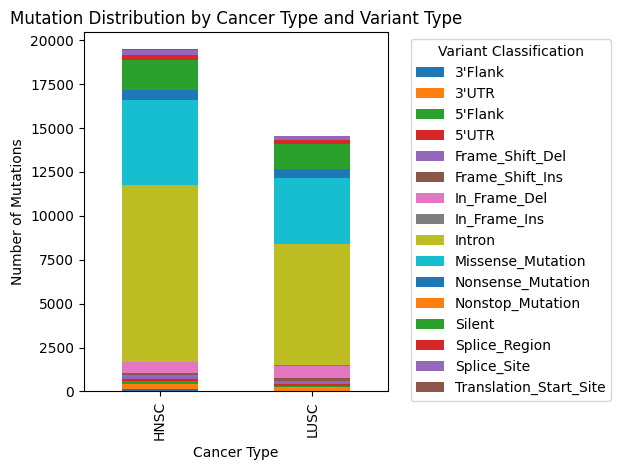

In [4]:
# Visualization for Task 1-C
print("Creating graphs for Task 1-C...")
train_muts_with_label = train_muts.merge(train_feats[['case_id', 'Label']], on='case_id', how='left')
if 'Label_y' in train_muts_with_label.columns:
    train_muts_with_label['Label'] = train_muts_with_label['Label_y']
    train_muts_with_label = train_muts_with_label.drop(columns=['Label_x', 'Label_y'])
grouped_data = train_muts_with_label.groupby(['Label', 'Variant_Classification']).size().unstack(fill_value=0)
grouped_data.index = grouped_data.index.map({1.0: 'HNSC', 2.0: 'LUSC'})
plt.figure(figsize=(12, 6))
grouped_data.plot(kind='bar', stacked=True)
plt.xlabel('Cancer Type')
plt.ylabel('Number of Mutations')
plt.title('Mutation Distribution by Cancer Type and Variant Type')
plt.legend(title='Variant Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('mutation_distribution_by_cancer_and_variant.png')
plt.show('mutation_distribution_by_cancer_and_variant.png')
plt.close()


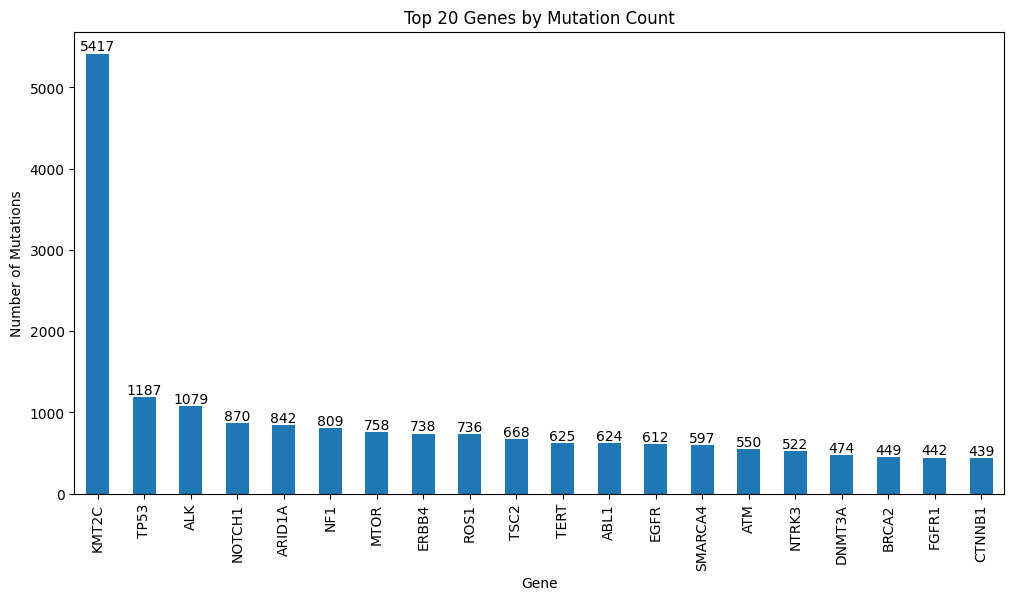

In [5]:
# Additional Graph: Mutation Count per Gene
gene_totals = train_muts.groupby('Gene_name').size().sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 6))
bars = gene_totals.plot(kind='bar')
plt.xlabel('Gene')
plt.ylabel('Number of Mutations')
plt.title('Top 20 Genes by Mutation Count')
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height())}',
             ha='center', va='bottom')
plt.savefig('mutation_distribution_by_gene.png')
plt.show('mutation_distribution_by_gene.png')
plt.close()

## Phase 4: Building and Evaluating Classifier for Task 1
### Training and Evaluating Classifiers
- We preprocess the data by removing constant features and selecting the top 100 features using `SelectKBest`.
- We train two classifiers (RandomForest and XGBoost) using `GridSearchCV` and evaluate them.
- Predictions are saved to `task1_predictions.csv`.

In [ ]:
# Classifier for Task 1
print("Training Task 1 classifier...")
train_data = train_features.merge(train_feats[['case_id', 'Label']], on='case_id')
X_train = train_data.drop(columns=['case_id', 'Label']).fillna(0)
y_train = train_data['Label'].astype(int) - 1
X_test = test_features.drop(columns=['case_id']).fillna(0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

feature_names = X_train.columns.tolist()
variance_threshold = VarianceThreshold(threshold=0)
X_train_var = variance_threshold.fit_transform(X_train)
X_test_var = variance_threshold.transform(X_test)
selector = SelectKBest(score_func=f_classif, k=100)
X_train_selected = selector.fit_transform(X_train_var, y_train)
X_test_selected = selector.transform(X_test_var)

variance_support = variance_threshold.get_support()
selector_support = selector.get_support(indices=True)
selected_feature_indices = variance_support.nonzero()[0][selector_support]
feature_names = [feature_names[i] for i in selected_feature_indices]

X_train_split, X_val, y_train_split, y_val = train_test_split(X_train_selected, y_train, test_size=0.2, stratify=y_train, random_state=42)
classifiers = {
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(device='cuda', tree_method='hist', random_state=42)
}
best_classifier = None
best_score = 0
best_threshold = 0.5

for name, classifier in classifiers.items():
    if name == 'RandomForest':
        param_grid = {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'min_samples_split': [2, 5]}
    else:
        param_grid = {'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.3], 'n_estimators': [100, 200, 300]}
    grid_search = GridSearchCV(classifier, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
    grid_search.fit(X_train_split, y_train_split)
    y_val_pred = grid_search.predict(X_val)
    error = (y_val_pred != y_val).mean()
    f1 = f1_score(y_val, y_val_pred, average='weighted')
    print(f"{name} - Validation error: {error}")
    print(f"{name} - F1-Score: {f1}")
    print(f"{name} - Precision: {precision_score(y_val, y_val_pred, average='weighted')}")
    print(f"{name} - Recall: {recall_score(y_val, y_val_pred, average='weighted')}")
    y_val_proba = grid_search.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
    optimal_idx = np.argmax(f1_scores[np.isfinite(f1_scores)])
    best_threshold = thresholds[optimal_idx]
    print(f"{name} - Optimal threshold: {best_threshold}")
    if f1 > best_score:
        best_score = f1
        best_classifier = grid_search.best_estimator_

# Save predictions
best_classifier.fit(X_train_selected, y_train)
y_test_proba = best_classifier.predict_proba(X_test_selected)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int) + 1
pd.DataFrame({'id_case': test_features['case_id'], 'label_predict': y_test_pred}).to_csv('task1_predictions.csv', index=False)

# Feature Importance Table
importances = best_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Threshold': best_threshold
})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
print("Feature Importance Table for Task 1:")
print(feature_importance_df.head(10))
feature_importance_df.to_csv('feature_importance_task1.csv', index=False)

# Generate and Save Confusion Matrix
print("Generating confusion matrix visualization...")
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred,
                                             labels=[0, 1],
                                             display_labels=['HNSC', 'LUSC'],
                                             cmap='Blues')
plt.title('Task 1: Mutation-Only Classification\nConfusion Matrix')
plt.tight_layout()
plt.savefig('out/confusion_matrix_task1.png', dpi=300, bbox_inches='tight')
plt.close()

Training Task 1 classifier...
RandomForest - Validation error: 0.33540372670807456
RandomForest - F1-Score: 0.6573037349582189
RandomForest - Precision: 0.676167844360064
RandomForest - Recall: 0.6645962732919255
RandomForest - Optimal threshold: 0.47856400735536836


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:55:54] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


XGBoost - Validation error: 0.3416149068322981
XGBoost - F1-Score: 0.6582532820372345
XGBoost - Precision: 0.6593934016294266
XGBoost - Recall: 0.6583850931677019
XGBoost - Optimal threshold: 0.054698001593351364
Feature Importance Table for Task 1:
                                  Feature  Importance  Threshold
42      Mutations_in_GLI1_Frame_Shift_Ins    0.026051   0.054698
82                Norm_Mutations_in_KMT2C    0.025589   0.054698
37         Mutations_in_TSC1_In_Frame_Del    0.022118   0.054698
81                  Norm_Mutations_in_KIT    0.021270   0.054698
88                 Norm_Mutations_in_PTEN    0.020291   0.054698
59                Mutations_in_WT1_Silent    0.019315   0.054698
49    Mutations_in_TSC1_Missense_Mutation    0.018413   0.054698
18               Mutations_in_MSH6_Intron    0.016899   0.054698
91                Norm_Mutations_in_RUNX1    0.016669   0.054698
29  Mutations_in_CDKN2A_Nonsense_Mutation    0.016502   0.054698


# Task 1: Classifier for Mutations Only
## Overview
This notebook implements the classifier for Task 1, focusing on mutation data only. It includes data loading, feature engineering, visualization, and model training using RandomForest and XGBoost.

### Confusion Matrix Interpretation

The confusion matrix visualizes the performance of our mutation-based classifier:
- Rows represent actual classes (True labels)
- Columns represent predicted classes
- Diagonal elements show correct predictions
- Off-diagonal elements show misclassifications

Key observations:
1. Classification accuracy varies between cancer subtypes
2. Any systematic misclassification patterns may suggest:
   - Shared mutation profiles between subtypes
   - Need for additional discriminative features
3. This baseline performance will be compared with Task 2's integrated approach

The confusion matrix is saved as `out/confusion_matrix_task1.png`.